# UIT-VSFC — Sentiment Analysis with SVM and Naive Bayes

**Yêu cầu:** *Perform sentiment analysis using SVM and Naive Bayes and compare the results.*

## 1. Load Dataset

Sử dụng **UIT-VSFC**, được liệt kê trong [nguồn GitHub của đề](https://github.com/undertheseanlp/NLP-Vietnamese-progress/blob/master/tasks/sentiment_analysis.md). Gắn dữ liệu đã giải nén vào Kaggle, giữ cấu trúc `train/` và `test/`.

Đọc `sents.txt` và `sentiments.txt` tương ứng từng dòng: **0 = negative, 1 = neutral, 2 = positive**. Dữ liệu gốc có **11,426 mẫu train**, **3,166 mẫu test**. Không dùng nhãn topic hoặc tập dev vì tham số được giữ cố định, không tuning.

Chạy bằng **CPU**, bật Internet để cài `underthesea`.


In [1]:
%pip install -q "underthesea==8.3.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.4/978.4 kB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 48.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import re
import unicodedata
from pathlib import Path
from time import perf_counter

import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import Markdown, display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from underthesea import word_tokenize

SEED = 42
LABELS = [0, 1, 2]
print('scikit-learn:', sklearn.__version__)

scikit-learn: 1.6.1


In [3]:
roots = sorted({p.parent.parent for p in Path('/kaggle/input').rglob('sents.txt')
                if p.parent.name == 'train' and (p.parent.parent / 'test/sents.txt').is_file()})
if len(roots) != 1:
    raise ValueError(f'Cần gắn đúng một bản UIT-VSFC đã giải nén. Các thư mục tìm thấy: {roots}')
DATA_DIR = roots[0]
CLASS_NAMES = ['negative', 'neutral', 'positive']
OUTPUT_NAME = 'uit_vsfc_results.csv'

def read_split(split):
    folder = DATA_DIR / split
    texts = (folder / 'sents.txt').read_text(encoding='utf-8-sig').splitlines()
    labels = (folder / 'sentiments.txt').read_text(encoding='utf-8-sig').splitlines()
    if len(texts) != len(labels):
        raise ValueError(f'{split}: số dòng văn bản và nhãn không khớp.')
    frame = pd.DataFrame({'text': texts, 'label': [int(x) for x in labels]})
    if not frame['label'].isin(LABELS).all():
        raise ValueError(f'{split}: nhãn sentiment phải thuộc 0, 1, 2.')
    return frame

raw_train, raw_test = read_split('train'), read_split('test')
print('Thư mục:', DATA_DIR)
print('Ban đầu — Train:', len(raw_train), '| Test:', len(raw_test))
display(raw_train.head())

Thư mục: /kaggle/input/datasets/solitudeshu/uit-vsfc/UIT-VSFC
Ban đầu — Train: 11426 | Test: 3166


,text,label
0,slide giáo trình đầy đủ .,2
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2
2,đi học đầy đủ full điểm chuyên cần .,0
3,chưa áp dụng công nghệ thông tin và các thiết ...,0
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2


## 2. Prepare Text

Chuẩn hóa Unicode NFC, lowercase, xóa HTML/URL/dấu câu, chuẩn hóa khoảng trắng và tách từ tiếng Việt bằng `underthesea`. Giữ dấu tiếng Việt và stopword, đặc biệt các từ phủ định như **không, chưa, chẳng**.


In [4]:
def preprocess(text):
    text = unicodedata.normalize('NFC', text).lower()
    text = re.sub(r'https?://\S+|www\.\S+|<[^>]+>', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return word_tokenize(text, format='text') if text else ''


def prepare_text(frame):
    frame = frame.dropna(subset=['text', 'label']).copy()
    frame['processed_text'] = frame['text'].map(preprocess)
    return frame.loc[frame['processed_text'].str.strip().ne('')].copy()


def deduplicate(frame):
    # Loại toàn bộ nhóm có cùng văn bản nhưng khác nhãn; giữ một mẫu nếu cùng nhãn.
    conflicts = frame.groupby('processed_text')['label'].transform('nunique').gt(1)
    return frame.loc[~conflicts].drop_duplicates('processed_text').reset_index(drop=True)

## 3. Train-Test Split

Giữ cách chia train/test gốc. Trong train, loại mẫu rỗng, trùng và nhóm có nhãn mâu thuẫn; loại thêm văn bản trùng test sau tiền xử lý bằng cách chỉ đối chiếu văn bản, không dùng nhãn test.

Train giảm **133 mẫu**, trong đó **46 mẫu trùng test**, còn **11,293 mẫu**. Test giữ nguyên **3,166 mẫu**. Đây là kết quả trên train đã làm sạch, không phải thiết lập benchmark nguyên bản.


In [5]:
train_df = deduplicate(prepare_text(raw_train))
test_df = prepare_text(raw_test).reset_index(drop=True)
overlap = train_df['processed_text'].isin(test_df['processed_text'])
print('Số mẫu train trùng văn bản test bị loại:', int(overlap.sum()))
train_df = train_df.loc[~overlap].reset_index(drop=True)
print('Tổng số mẫu bị loại — Train:', len(raw_train) - len(train_df),
      '| Test:', len(raw_test) - len(test_df))

assert set(y for y in train_df['label']) == set(LABELS)
assert set(y for y in test_df['label']) == set(LABELS)
assert set(train_df['processed_text']).isdisjoint(test_df['processed_text'])
distribution = pd.DataFrame({
    'Train': train_df['label'].value_counts(),
    'Test': test_df['label'].value_counts(),
}).reindex(LABELS).fillna(0).astype(int)
distribution.index = CLASS_NAMES
display(distribution)
display(train_df[['text', 'processed_text', 'label']].head(3))

Số mẫu train trùng văn bản test bị loại: 46
Tổng số mẫu bị loại — Train: 133 | Test: 0


,Train,Test
negative,5317,1409
neutral,444,167
positive,5532,1590


,text,processed_text,label
0,slide giáo trình đầy đủ .,slide giáo_trình đầy_đủ,2
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",nhiệt_tình giảng_dạy gần_gũi với sinh_viên,2
2,đi học đầy đủ full điểm chuyên cần .,đi học đầy_đủ full_điểm chuyên cần,0


## 4. TF-IDF Features

Dùng chung **TF-IDF unigram + bigram**, tối đa **20,000 đặc trưng**, cho cả hai mô hình. Chỉ học vocabulary và IDF trên train; test chỉ được `transform` để tránh rò rỉ dữ liệu.

TF-IDF có giá trị không âm, phù hợp với Multinomial Naive Bayes. 

In [6]:
vectorizer = TfidfVectorizer(
    tokenizer=str.split, token_pattern=None, lowercase=False,
    ngram_range=(1, 2), min_df=2, max_features=20000, sublinear_tf=True,
)
X_train = vectorizer.fit_transform(train_df['processed_text'])
X_test = vectorizer.transform(test_df['processed_text'])
y_train = train_df['label']
y_test = test_df['label']
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (11293, 12996) | Test: (3166, 12996)


## 5. Train and Compare Models

- **SVM (`LinearSVC`)** học ranh giới tuyến tính với biên phân cách lớn, cân bằng với lỗi huấn luyện qua `C`. Dùng `C=1.0`; phân loại nhiều lớp theo one-vs-rest.
- **Naive Bayes (`MultinomialNB`)** áp dụng định lý Bayes với giả định các đặc trưng độc lập có điều kiện theo lớp. Dùng `alpha=1.0` (Laplace smoothing) để tránh xác suất bằng 0 cho đặc trưng chưa xuất hiện trong lớp.

Hai mô hình dùng cùng dữ liệu và ma trận TF-IDF, giữ cố định tham số. So sánh chính bằng **Macro-F1** (trung bình F1 với trọng số bằng nhau cho các lớp), kèm Accuracy, Precision và Recall. Thời gian trong bảng chỉ tính `fit`/`predict` của bộ phân loại, không gồm tiền xử lý và TF-IDF.


In [7]:
models = {
    'SVM': LinearSVC(C=1.0, dual=True, max_iter=10000, random_state=SEED),
    'Naive Bayes': MultinomialNB(alpha=1.0),
}
rows, predictions, reports = [], {}, {}
for name, model in models.items():
    start = perf_counter()
    model.fit(X_train, y_train)
    train_seconds = perf_counter() - start
    start = perf_counter()
    pred = model.predict(X_test)
    predict_seconds = perf_counter() - start
    predictions[name] = pred
    report = classification_report(
        y_test, pred, labels=LABELS, target_names=CLASS_NAMES,
        output_dict=True, zero_division=0,
    )
    reports[name] = pd.DataFrame(report).T
    rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision (macro)': report['macro avg']['precision'],
        'Recall (macro)': report['macro avg']['recall'],
        'F1 (macro)': report['macro avg']['f1-score'],
        'Train (s)': train_seconds,
        'Predict (s)': predict_seconds,
    })

results = pd.DataFrame(rows).set_index('Model')
display(results.round(4))

,Accuracy,Precision (macro),Recall (macro),F1 (macro),Train (s),Predict (s)
Model,,,,,,
SVM,0.8948,0.7939,0.6801,0.6981,0.1017,0.0009
Naive Bayes,0.8699,0.5809,0.6137,0.5956,0.0055,0.0008


## 6. Per-Class Evaluation

Báo cáo Precision, Recall, F1 và số mẫu (`support`) của từng lớp. Confusion matrix có hàng là nhãn thật, cột là nhãn dự đoán; các ô ngoài đường chéo thể hiện lỗi phân loại.


### SVM

,precision,recall,f1-score,support
negative,0.8750,0.9539,0.9127,1409.0
neutral,0.5833,0.1677,0.2605,167.0
positive,0.9235,0.9189,0.9212,1590.0


### Naive Bayes

,precision,recall,f1-score,support
negative,0.8250,0.9567,0.8860,1409.0
neutral,0.0000,0.0000,0.0000,167.0
positive,0.9178,0.8843,0.9007,1590.0


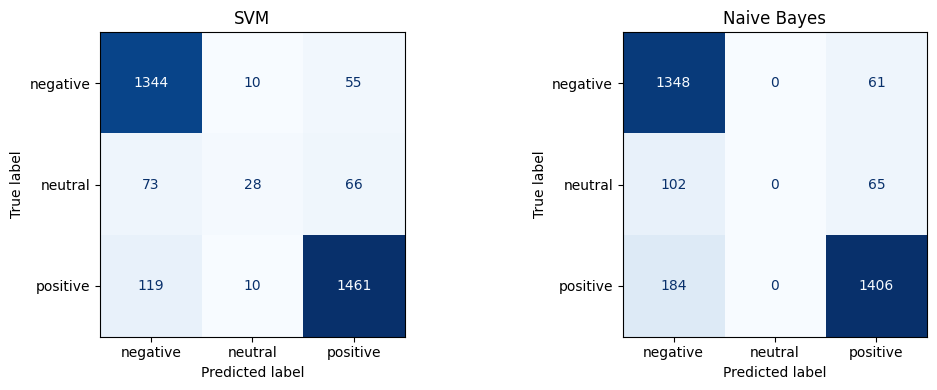

In [8]:
for name, report in reports.items():
    display(Markdown(f'### {name}'))
    display(report.loc[CLASS_NAMES, ['precision', 'recall', 'f1-score', 'support']].round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, pred) in zip(axes, predictions.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred, labels=LABELS, display_labels=CLASS_NAMES,
        cmap='Blues', colorbar=False, ax=ax,
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()

## 7. Results and Conclusion

SVM tốt hơn theo Macro-F1, nhưng cả hai mô hình còn yếu ở lớp **neutral**, chỉ chiếm **167/3,166 mẫu test (5.27%)**. SVM nhận đúng **28/167** mẫu neutral; Naive Bayes không dự đoán mẫu nào thuộc lớp này. Vì vậy Accuracy cao chưa phản ánh đầy đủ khả năng phân loại cả ba lớp; cần ưu tiên Macro-F1 và F1 từng lớp.

Kết luận chỉ áp dụng cho cấu hình và tập test hiện tại. Thời gian toàn notebook theo log Kaggle là **53.3 giây**. Cell dưới báo cáo số liệu và xuất bảng CSV.


In [9]:
delta = results.loc['SVM', 'F1 (macro)'] - results.loc['Naive Bayes', 'F1 (macro)']
if abs(delta) < 1e-12:
    comparison = 'Hai mô hình có Macro-F1 bằng nhau trên tập test này.'
else:
    better = 'SVM' if delta > 0 else 'Naive Bayes'
    comparison = f'{better} có Macro-F1 cao hơn {abs(delta) * 100:.2f} điểm phần trăm trên tập test này.'
notes = [comparison]
for name in models:
    row = results.loc[name]
    weakest = reports[name].loc[CLASS_NAMES, 'f1-score'].idxmin()
    notes.append(
        f"**{name}**: Accuracy = {row['Accuracy']:.4f}, Macro-F1 = {row['F1 (macro)']:.4f}; "
        f"lớp có F1 thấp nhất là **{weakest}** ({reports[name].loc[weakest, 'f1-score']:.4f})."
    )
faster = results['Train (s)'].idxmin()
notes.append(f'{faster} có thời gian huấn luyện ngắn hơn trong lần chạy này; thời gian phụ thuộc môi trường CPU.')
display(Markdown('\n\n'.join(notes)))

output_dir = Path('/kaggle/working')
output_dir.mkdir(parents=True, exist_ok=True)
results.to_csv(output_dir / OUTPUT_NAME, encoding='utf-8-sig')

SVM có Macro-F1 cao hơn 10.26 điểm phần trăm trên tập test này.

**SVM**: Accuracy = 0.8948, Macro-F1 = 0.6981; lớp có F1 thấp nhất là **neutral** (0.2605).

**Naive Bayes**: Accuracy = 0.8699, Macro-F1 = 0.5956; lớp có F1 thấp nhất là **neutral** (0.0000).

Naive Bayes có thời gian huấn luyện ngắn hơn trong lần chạy này; thời gian phụ thuộc môi trường CPU.